# Fit and visualize a Doohan hierarchical LMDP

This notebook reproduces the data setup and trial assembly from `doohan_trial_lmdp.ipynb`, fits a fresh distributed hierarchy to those trials with Adam, materializes the best parameter snapshot as a new NumPy hierarchy, and visualizes that fitted hierarchy with the hierarchical diagnostic plots.


## 1. Setup paths, select sessions, and build the shared maze

In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    raise FileNotFoundError("Run this notebook from the project or notebook directory")

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from andrew_mlmdp import (  # noqa: E402
    DoohanDataset,
    Environment,
    NMFConfig,
    SubgoalBasis,
    discover_subgoals,
    fittable_parameters,
    score_hierarchy_dataset,
    soft_parameters,
)
from andrew_mlmdp import (  # noqa: E402
    plotting as viz,
)

GRIDMAZE_DATA = (
    PROJECT_ROOT / "external" / "GridMaze-mFC-ephys-DATA" / "data"
)

SUBJECT_IDS = ["m2"]
MAZE_NAME = "maze_1"
START_DATE = "2022-06-28"
END_DATE = "2022-07-05"

movement_dataset = DoohanDataset.from_data_root(
    GRIDMAZE_DATA,
    subject_ids=SUBJECT_IDS,
    start_date=START_DATE,
    end_date=END_DATE,
    maze_name=MAZE_NAME,
)
sessions = movement_dataset.sessions
labeled_maze = movement_dataset.definition
maze = labeled_maze.maze
environment = Environment(maze)

print(f"sessions: {len(sessions)}")
print(f"maze: {movement_dataset.maze_name}")
print(f"tower grid shape: {maze.shape}")
print(f"physical states: {len(maze.free_cells)}")

sessions: 8
maze: maze_1
tower grid shape: (7, 7)
physical states: 49


## 2. Inspect the assembled navigation trials

The Doohan movement dataset owns session discovery and trial extraction. It removes missing positions and bridge labels, collapses consecutive towers, converts labels to coordinates, truncates each trajectory at its first goal entry, and retains malformed sessions or trials as explicit exclusions.

In [2]:
movement_trials = list(movement_dataset.trials)
exclusion_rows = [
    {
        "session": exclusion.session_id,
        "trial": exclusion.trial_id,
        "goal": exclusion.goal_label,
        "transitions": 0,
        "flat_log_likelihood": float("nan"),
        "hierarchical_log_likelihood": float("nan"),
        "status": "excluded",
        "exclusion_reason": f"data: {exclusion.reason}",
    }
    for exclusion in movement_dataset.exclusions
]

print(f"valid trials: {len(movement_trials)}")
print(f"data exclusions: {len(exclusion_rows)}")

valid trials: 522
data exclusions: 0


## 3. Discover the distributed basis and construct the initial hierarchy

The NMF basis is discovered once from the shared maze. The hierarchy below is the unfitted starting point for Adam; fitting will not mutate it.


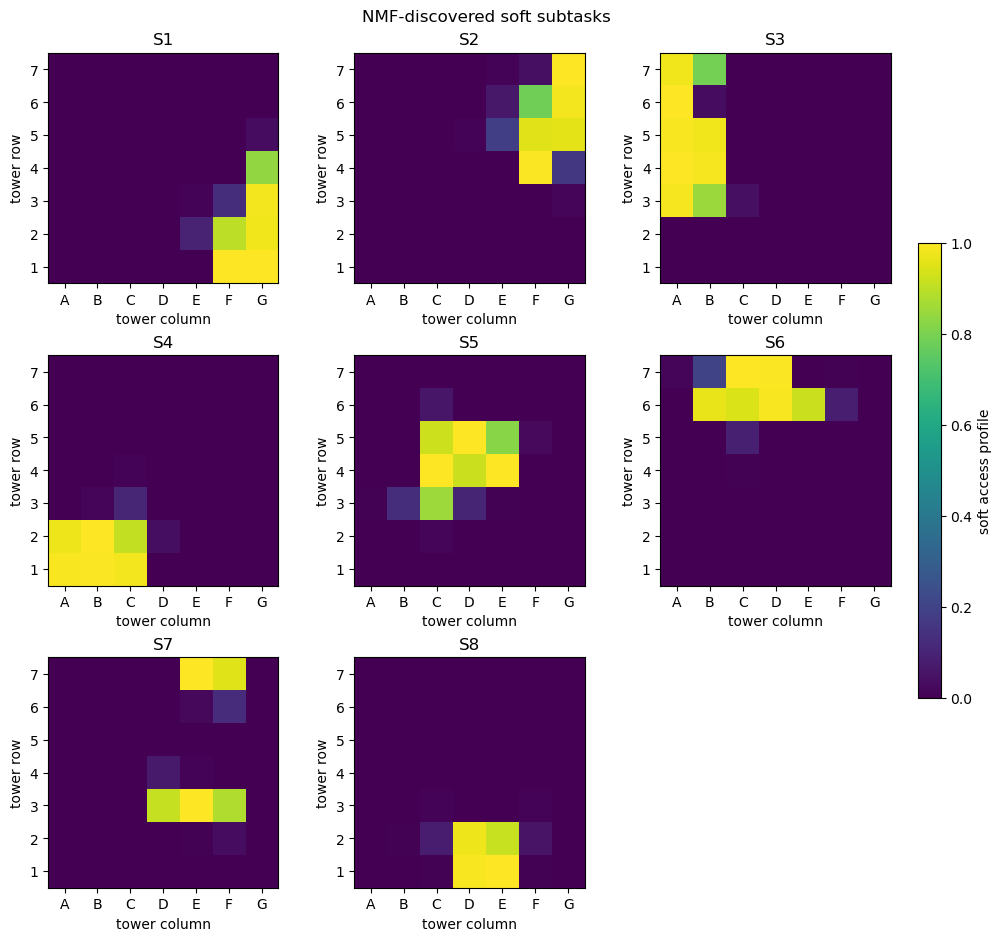

active fitted parameters: ('lower_control_cost', 'upper_control_cost', 'alpha', 'beta', 'core_threshold', 'core_exponent')


In [4]:
import numpy as np

from andrew_mlmdp.hierarchy import (
    sample_rollouts,
    sweep_diagnostics,
)

DISCOVERY_RANK = 8
DISCOVERY_CONTROL_COST = 1
DISCOVERY_SEED = 0

soft_discovery = discover_subgoals(
    environment,
    ranks=(DISCOVERY_RANK,),
    parameters=NMFConfig(control_cost=DISCOVERY_CONTROL_COST),
    seed=DISCOVERY_SEED,
).result(DISCOVERY_RANK)
viz.plot_subtasks(soft_discovery)
plt.show()

soft_basis = SubgoalBasis.from_profiles(
    maze,
    soft_discovery.profiles,
    core_threshold=0.8,
)
initial_hierarchy_template = environment.hierarchy(
    soft_basis,
    parameters=soft_parameters(
        DISCOVERY_RANK,
        upper_control_cost=1.8,
    ),
)

print(
    "active fitted parameters:",
    fittable_parameters(initial_hierarchy_template),
)


## 4. Fit the hierarchy with multiple Adam restarts

Trials with nonfinite likelihood under the baseline hierarchy are excluded before optimization. Adam is deterministic for a fixed initial condition, so this section fits the same model from one baseline and four reproducibly perturbed parameter vectors. The run with the highest finite training log-likelihood supplies the parameter snapshot used by every downstream diagnostic.


In [5]:
initial_hierarchical_report = movement_dataset.report(
    score_hierarchy_dataset(
        initial_hierarchy_template,
        movement_trials,
    )
)
finite_trial_keys = {
    (score.session_id, score.trial_id)
    for score in initial_hierarchical_report.result.trial_likelihoods
    if math.isfinite(score.log_likelihood)
}
fitting_trials = tuple(
    trial
    for trial in movement_trials
    if (trial.session_id, trial.trial_id) in finite_trial_keys
)
omitted_trial_count = len(movement_trials) - len(fitting_trials)

print(f"fitting trials: {len(fitting_trials)}")
print(f"omitted nonfinite initial trials: {omitted_trial_count}")
if not fitting_trials:
    raise RuntimeError("No trials have a finite initial hierarchy likelihood")


fitting trials: 522
omitted nonfinite initial trials: 0


In [ ]:
FIT_LEARNING_RATE = 8e-2
FIT_MAX_STEPS = 1000
FIT_RELATIVE_TOLERANCE = 1e-4
FIT_PATIENCE = 20
FIT_LR_DECAY_FACTOR = 0.3
FIT_LR_DECAY_PATIENCE = 7
FIT_MINIMUM_LEARNING_RATE = 1e-4
FIT_SCHEDULER_RELATIVE_THRESHOLD = 3e-4

N_RESTARTS = 1
RESTART_SEED = 123
RESTART_LOG_SCALE = 0.45
fit_names = fittable_parameters(initial_hierarchy_template)
base_parameter_values = initial_hierarchy_template.parameter_values()
base_values = {
    name: float(base_parameter_values[name].detach())
    for name in fit_names
}
fit_goals = {trial.goal for trial in fitting_trials}
threshold_cap = np.nextafter(
    initial_hierarchy_template.threshold_range(fit_goals).maximum,
    -np.inf,
)
positive_names = (
    "lower_control_cost",
    "upper_control_cost",
    "alpha",
    "beta",
    "core_exponent",
)

random_generator = np.random.default_rng(RESTART_SEED)
initial_conditions = [base_values]
for _ in range(N_RESTARTS - 1):
    values = base_values.copy()
    for name in positive_names:
        values[name] *= np.exp(
            random_generator.normal(0.0, RESTART_LOG_SCALE)
        )
    values["core_threshold"] = random_generator.uniform(
        0.35 * threshold_cap,
        0.90 * threshold_cap,
    )
    initial_conditions.append(values)

progress_display = display(
    "Waiting for the first Adam evaluation...",
    display_id=True,
)
restart_results = []
restart_rows = []

for restart_index, initial_values in enumerate(initial_conditions):
    restart_number = restart_index + 1
    restart_basis = SubgoalBasis.from_profiles(
        maze,
        soft_basis.profiles,
        core_threshold=initial_values["core_threshold"],
        core_exponent=initial_values["core_exponent"],
        labels=soft_basis.labels,
    )
    restart_template = environment.hierarchy(
        restart_basis,
        parameters=soft_parameters(
            DISCOVERY_RANK,
            **initial_values,
        ),
        task_library=initial_hierarchy_template.task_library,
        composition_exponent=(
            initial_hierarchy_template.composition_exponent
        ),
        composition_mode=initial_hierarchy_template.composition_mode,
    )

    def show_fit_progress(evaluation, restart_number=restart_number):
        completed = min(evaluation.updates, FIT_MAX_STEPS)
        fraction = completed / max(1, FIT_MAX_STEPS)
        filled = round(30 * fraction)
        bar = "█" * filled + "·" * (30 - filled)
        best_loss = evaluation.best_loss
        best_loss_text = (
            "n/a" if best_loss is None else f"{best_loss:.6f}"
        )
        progress_display.update(
            f"restart {restart_number}/{N_RESTARTS} "
            f"[{bar}] {completed}/{FIT_MAX_STEPS} updates | "
            f"loss={evaluation.loss:.6f} | best={best_loss_text} | "
            f"lr={evaluation.lr:.3e} | "
            f"gradient norm={evaluation.gradient_norm:.3e}"
        )

    result = restart_template.fit(
        fitting_trials,
        names=fit_names,
        lr=FIT_LEARNING_RATE,
        max_steps=FIT_MAX_STEPS,
        tolerance=FIT_RELATIVE_TOLERANCE,
        patience=FIT_PATIENCE,
        lr_decay=FIT_LR_DECAY_FACTOR,
        lr_patience=FIT_LR_DECAY_PATIENCE,
        min_lr=FIT_MINIMUM_LEARNING_RATE,
        scheduler_tolerance=FIT_SCHEDULER_RELATIVE_THRESHOLD,
        callback=show_fit_progress,
    )
    finite_restart_evaluations = [
        evaluation
        for evaluation in result.history
        if math.isfinite(evaluation.log_likelihood)
    ]
    if result.best_values is None or not finite_restart_evaluations:
        restart_rows.append(
            {
                "restart": restart_number,
                "best_total_log_likelihood": np.nan,
                "updates": result.updates,
                "reason": result.reason,
                "converged": result.converged,
            }
        )
        continue

    restart_best = max(
        finite_restart_evaluations,
        key=lambda evaluation: evaluation.log_likelihood,
    )
    restart_results.append(
        {
            "restart": restart_number,
            "template": restart_template,
            "result": result,
            "best_log_likelihood": restart_best.log_likelihood,
        }
    )
    restart_rows.append(
        {
            "restart": restart_number,
            "best_total_log_likelihood": restart_best.log_likelihood,
            "updates": result.updates,
            "reason": result.reason,
            "converged": result.converged,
        }
    )

if not restart_results:
    raise RuntimeError("Every Adam restart failed before finding a finite state")

winner = max(
    restart_results,
    key=lambda run: run["best_log_likelihood"],
)
winning_restart = winner["restart"]
winning_log_likelihood = winner["best_log_likelihood"]
initial_hierarchy_template = winner["template"]
fit_result = winner["result"]
best_parameter_values = fit_result.best_values.as_floats()
optimal_parameter_values = {
    name: best_parameter_values[name]
    for name in fit_names
}
finite_evaluations = [
    evaluation
    for evaluation in fit_result.history
    if math.isfinite(evaluation.loss)
]
best_evaluation = min(finite_evaluations, key=lambda item: item.loss)

restart_summary = pd.DataFrame(restart_rows).set_index("restart")
fit_summary = pd.DataFrame(
    [
        {
            "restarts": N_RESTARTS,
            "winning_restart": winning_restart,
            "fitted_trials": len(fitting_trials),
            "omitted_initial_nonfinite": omitted_trial_count,
            "optimizer_updates": fit_result.updates,
            "reason": fit_result.reason,
            "converged": fit_result.converged,
            "initial_total_log_likelihood": (
                fit_result.history[0].log_likelihood
            ),
            "best_total_log_likelihood": (
                best_evaluation.log_likelihood
            ),
        }
    ]
)
parameter_table = pd.DataFrame(
    {
        "initial_value": pd.Series(
            {
                name: fit_result.initial_values.as_floats()[name]
                for name in fit_names
            }
        ),
        "optimal_value": pd.Series(optimal_parameter_values),
    }
).rename_axis("parameter")

progress_display.update(
    f"selected restart {winning_restart}/{N_RESTARTS} | "
    f"log likelihood={winning_log_likelihood:.6f}"
)
display(restart_summary)
display(fit_summary)
display(parameter_table)


'restart 1/1 [······························] 15/1000 updates | loss=4934.632518 | best=4934.632518 | lr=8.000e-02 | gradient norm=5.955e+02'

In [ ]:
fit_history = pd.DataFrame(
    {
        "evaluation": [item.evaluation for item in fit_result.history],
        "loss": [item.loss for item in fit_result.history],
        "best_loss": [item.best_loss for item in fit_result.history],
        "lr": [
            item.lr for item in fit_result.history
        ],
    }
)
fig, loss_ax = plt.subplots(figsize=(10, 4.5))
loss_ax.plot(fit_history["evaluation"], fit_history["loss"], label="loss")
loss_ax.plot(
    fit_history["evaluation"],
    fit_history["best_loss"],
    label="best loss",
)
loss_ax.set_xlabel("Adam evaluation")
loss_ax.set_ylabel("negative total log-likelihood")
loss_ax.legend(loc="upper right")
learning_rate_ax = loss_ax.twinx()
learning_rate_ax.step(
    fit_history["evaluation"],
    fit_history["lr"],
    color="#d95f02",
    alpha=0.6,
    where="post",
)
learning_rate_ax.set_yscale("log")
learning_rate_ax.set_ylabel("Adam learning rate")
loss_ax.set_title("Hierarchy fitting history")
fig.tight_layout()
plt.show()


## 5. Materialize the best fit as a fresh hierarchy

`fit_parameters` deliberately leaves the original template unchanged. The best snapshot is therefore used to rebuild the gated basis and the model parameters explicitly. All following diagnostics consume this fresh fitted hierarchy.


In [ ]:
fitted_basis = SubgoalBasis.from_profiles(
    maze,
    soft_basis.profiles,
    core_threshold=optimal_parameter_values["core_threshold"],
    core_exponent=optimal_parameter_values["core_exponent"],
    labels=soft_basis.labels,
)
fitted_parameters = soft_parameters(
    DISCOVERY_RANK,
    **optimal_parameter_values,
)
fitted_hierarchy_template = environment.hierarchy(
    fitted_basis,
    parameters=fitted_parameters,
    task_library=initial_hierarchy_template.task_library,
    composition_exponent=initial_hierarchy_template.composition_exponent,
    composition_mode=initial_hierarchy_template.composition_mode,
)

EXAMPLE_TRIAL_INDEX = 0
example_trial = fitting_trials[EXAMPLE_TRIAL_INDEX]
example_start = example_trial.trajectory[0]
example_goal = example_trial.goal
fitted_task = fitted_hierarchy_template.task(example_goal)

print(
    f"visualized trial: {example_trial.session_id}, "
    f"trial {example_trial.trial_id}"
)
print(f"start: {example_start}; goal: {example_goal}")
print(f"subgoals: {fitted_task.n_subtasks}")


## 6. Inspect the fitted access representations and upper dynamics

The first figure keeps the original NMF profiles, gated profiles, and task-level execution-access probabilities distinct. The second compares passive and fitted goal-conditioned controlled upper dynamics from the selected physical start.


In [ ]:
fig, axes = viz.plot_upper_graph(
    fitted_task,
    show_original_profiles=True,
    show_gated_profiles=True,
)
plt.show()

fig, axes = viz.plot_upper_policy(
    fitted_task,
    start_state=example_start,
    compare_passive=True,
)
plt.show()


## 7. Inspect fitted continuation policies and refractory departures

Each representative coordinate below is selected only from positive task-level execution-access support. It is passed explicitly as an entry coordinate so the purple arrow shows the actual first post-access refractory-adjusted distribution; display peaks are never treated as entry states.


In [ ]:
entry_coordinates = {}
for subgoal_index in range(fitted_task.n_subtasks):
    access_probabilities = fitted_task.subtask_access[subgoal_index]
    interior_index = int(np.argmax(access_probabilities))
    if access_probabilities[interior_index] > 0.0:
        physical_state = int(fitted_task.interior_states[interior_index])
        entry_coordinates[subgoal_index] = maze.coordinate(physical_state)

fig, axes = viz.plot_continuation_policies(
    fitted_task,
    quantity="log_desirability",
    entry_coordinates=entry_coordinates,
    show_refractory=True,
)
plt.show()


## 8. Inspect the fitted initial composition pipeline

These panels show the exact internal `raw_weights → clipped_weights → weights` pipeline for the selected start state, with the physical-goal component separated.


In [ ]:
fig, axes = viz.plot_composition_weights(
    fitted_task,
    start_state=example_start,
)
plt.show()


## 9. Compare fitted physical and latent rollout distributions

One seeded rollout ensemble drives both figures. Physical trajectory lengths are measured as physical steps only. The observed comparison uses every fitted trial with the same start and goal as the selected trial, so model and data are in identical per-rollout units.


In [ ]:
ROLLOUT_COUNT = 250
ROLLOUT_SEED = 7

rollout_ensemble = sample_rollouts(
    fitted_task,
    example_start,
    n_rollouts=ROLLOUT_COUNT,
    seed=ROLLOUT_SEED,
    max_steps=500,
)
matching_observed_trajectories = tuple(
    trial.trajectory
    for trial in fitting_trials
    if trial.trajectory[0] == example_start and trial.goal == example_goal
)

fig, axes = viz.plot_rollout_distribution(
    fitted_task,
    example_start,
    ensemble=rollout_ensemble,
    observed_trajectories=matching_observed_trajectories,
)
plt.show()

fig, axes = viz.plot_routes(
    fitted_task,
    example_start,
    ensemble=rollout_ensemble,
    top_n=10,
)
plt.show()


## 10. Compare pairwise policy entropy and trajectory length

This sensitivity analysis changes only the public lower_control_cost value on the fitted hierarchy for the selected start and goal. Each point builds the one-step controller dynamics once and reuses them for exact first-departure policy entropy and exact physical-step hitting-time moments. The shaded band is +/-1 intrinsic trajectory-length SD, not Monte Carlo standard error; the dashed horizontal line is the topology-only shortest path.

In [ ]:
LOWER_CONTROL_COST_SWEEP_VALUES = np.linspace(0.1, 5.0, 50)

lower_control_cost_pair_sweep = sweep_diagnostics(
    fitted_hierarchy_template,
    parameter_name="lower_control_cost",
    values=LOWER_CONTROL_COST_SWEEP_VALUES,
    start=example_start,
    goal=example_goal,
    progress=True,
    check_condition=False,
)

fig, (entropy_ax, length_ax) = viz.plot_diagnostic_sweep(
    lower_control_cost_pair_sweep,
)
fitted_lower_control_cost = float(
    fitted_parameters.lower_control_cost.item()
)
for axis in (entropy_ax, length_ax):
    axis.axvline(
        fitted_lower_control_cost,
        color="black",
        linestyle=":",
        label=f"fitted value = {fitted_lower_control_cost:.3g}",
    )
    axis.legend()
fig.tight_layout()
plt.show()
